# Entregável 2: Avaliação da Qualidade do Sinal (SQI)
**Disciplina:** Aquisição e Processamento de Biossinais  
**Equipe:** José Ferreira Lessa & Matheus Rocha Gomes da Silva  
**Orientador:** Prof. Dr. Victor Hugo C. de Albuquerque  
**Dataset:** PTB-XL — A Large Publicly Available Electrocardiography Dataset (PhysioNet)  
**Referência:** Wagner et al. (2020). PTB-XL, a large publicly available electrocardiography dataset. *Scientific Data*, 7(1), 154.  
**Data:** Março e Abril de 2026

---

## Objetivo
Neste notebook, vamos atribuir a cada registro do PTB-XL um índice objetivo de qualidade de sinal (SQI — *Signal Quality Index*) baseado em múltiplas métricas extraídas diretamente dos sinais brutos. A partir desse score, cada registro será categorizado em níveis de qualidade (A, B ou C), determinando quais seguirão adiante no pipeline e quais serão descartados por ruído irrecuperável.

## Objetivo

Este notebook descreve a etapa de **Avaliação de Qualidade dos Biossinais**, com foco na quantificação da qualidade dos sinais de ECG do dataset PTB-XL por meio de índices objetivos. O objetivo é identificar registros adequados para análise clínica e modelagem, bem como detectar sinais degradados por ruídos ou artefatos. São abordados:

1. **Preparação do Ambiente:** Importação de dependências, definição de parâmetros globais e organização dos caminhos de dados e saída.
2. **Carregamento dos Metadados Enriquecidos:** Utilização do dataset previamente estruturado, contendo informações clínicas, demográficas e anotações auxiliares.
3. **Carregamento dos Sinais de ECG:** Leitura dos sinais brutos no formato WFDB, preservando as características originais de aquisição.
4. **Cálculo de Índices de Qualidade (SQI):** Extração de métricas no domínio do tempo e da frequência para avaliação da integridade dos sinais.
5. **Agregação e Classificação da Qualidade:** Combinação das métricas em um índice global por registro, com categorização em níveis de qualidade.
6. **Análise e Interpretação dos Resultados:** Exploração dos índices obtidos e sua relação com os metadados disponíveis.

> **Nota metodológica:** A avaliação de qualidade é realizada diretamente sobre os sinais brutos, sem aplicação de etapas de pré-processamento corretivo. Essa escolha permite caracterizar fielmente as condições originais de aquisição e identificar artefatos reais presentes nos registros.

A saída deste notebook consiste em um conjunto de métricas de qualidade associadas a cada registro, que poderão ser utilizadas para filtragem, análise exploratória e suporte às etapas posteriores do pipeline.

## 1. Importações e Dependências
Além dos pacotes já anteriormente usados, importamos 
* `scipy.stats` para kurtosis e skewness e 
* `tqdm` para acompanhamento da barra de progresso no processamento em lote.

In [1]:
import os
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import wfdb
import scipy.signal as signal
import scipy.stats as stats                   # Novo em Relação ao Entregável 1
from pathlib import Path
from tqdm import tqdm                # Novo em Relação ao Entregável 1
from IPython.display import display, Markdown
#from collections import Counter             # não utilizado aqui
import warnings

warnings.filterwarnings('ignore', category=UserWarning)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

np.random.seed(42)

## 2. Configurações Globais

In [2]:
FS = 100
N_LEADS = 12
LEAD_NAMES = ['I', 'II', 'III', 'aVL', 'aVR', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
FOLDS_TREINO = [1, 2, 3, 4, 5, 6, 7, 8]
FOLD_VAL = 9
FOLD_TEST = 10

DATA_DIR = '../../../data/ptb-xl/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/'
FIGS_DIR = Path('../figuras')
OUT_DIR  = Path('../outputs')
for d in [FIGS_DIR, OUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('Configuração concluída.')
print(f'Figuras em: {FIGS_DIR.resolve()}')
print(f'Outputs em: {OUT_DIR.resolve()}')

Configuração concluída.
Figuras em: C:\Users\User\Desktop\repo-lessa\entregaveis\entregavel-2\figuras
Outputs em: C:\Users\User\Desktop\repo-lessa\entregaveis\entregavel-2\outputs


## 3. Carregamento dos Metadados Enriquecidos
Partimos do arquivo gerado no Entregável 1, que já contém as colunas de superclasse diagnóstica, ritmos, formas, split e flags de qualidade.

In [3]:
print("Carregando metadados do Entregável 1...")
caminho_metadados = '../../entregavel-1/outputs/ptbxl_metadata_enriched.csv'

if not os.path.exists(caminho_metadados):
    raise FileNotFoundError(f"Arquivo não encontrado: {caminho_metadados}\nExecute o Entregável 1 primeiro.")

df = pd.read_csv(caminho_metadados, index_col='ecg_id')
df['scp_codes'] = df['scp_codes'].apply(ast.literal_eval)
df['superclasses_clean'] = df['superclasses_clean'].apply(ast.literal_eval)

scp_statements = pd.read_csv(os.path.join(DATA_DIR, 'scp_statements.csv'), index_col=0)

print(f"Dataset carregado: {df.shape[0]} registros, {df.shape[1]} colunas.")

Carregando metadados do Entregável 1...
Dataset carregado: 21799 registros, 34 colunas.


---
## Seção 1 — Estratégia de Amostragem para Cálculo do SQI

### 1.1 Processamento em Lote

Nesta etapa, definimos uma função utilitária responsável por carregar os sinais de ECG diretamente dos arquivos no formato WFDB.

O objetivo é permitir a leitura eficiente dos registros a partir de seus identificadores (`ecg_id`), convertendo-os em arrays NumPy que poderão ser utilizados nas etapas posteriores de cálculo dos índices de qualidade (SQI).

A função considera a frequência de amostragem desejada (100 Hz ou 500 Hz), garantindo consistência na análise mesmo que a frequência FS seja diferente da usada durante a elaboração do pipeline.

In [4]:
def load_ecg(ecg_id, dataframe, path_base, fs):
    """
    Carrega o sinal de ECG a partir dos arquivos WFDB do PTB-XL.

    Parâmetros:
    - ecg_id: identificador do exame no dataframe
    - dataframe: tabela com os metadados (df)
    - path_base: caminho base onde estão os arquivos .dat/.hea
    - fs: frequência de amostragem desejada (100 ou 500 Hz)

    Retorna:
    - sig_arr: array NumPy com o sinal (n_amostras x 12 derivações)
    """

    # Seleciona a linha correspondente ao ECG
    linha = dataframe.loc[ecg_id]

    # Escolhe o arquivo correto conforme a frequência
    file_target = linha['filename_lr'] if fs == 100 else linha['filename_hr']

    # Lê o sinal utilizando WFDB
    signal_arr, _ = wfdb.rdsamp(os.path.join(path_base, file_target))

    return signal_arr

### 1.2 Verificação de Consistência dos Metadados de Qualidade

Antes de calcular os índices de qualidade, é importante avaliar a distribuição das anotações de qualidade já disponíveis no dataset.

O PTB-XL inclui flags indicando possíveis problemas no sinal (como *baseline drift*, ruído estático e problemas de eletrodo). Embora essas anotações não sejam utilizadas diretamente como rótulos no cálculo do SQI, elas servem como referência para validação posterior.

Nesta etapa, analisamos:
- A proporção de registros com e sem problemas de qualidade
- A distribuição desses problemas entre os diferentes *folds*

Isso permite identificar possíveis vieses de coleta ou concentração de ruído em subconjuntos específicos do dataset.

In [5]:
# Contagem de registros com/sem problemas de qualidade
qtd_issues = df['has_quality_issues'].value_counts()

# Percentual de registros "limpos"
pct_limpos = (qtd_issues.get(False, 0) / len(df)) * 100

display(Markdown(f"""
**Resumo dos metadados de qualidade originais:**
- **{pct_limpos:.2f}%** dos registros não possuem nenhuma anotação de problema de qualidade.
- Os demais possuem ao menos um indicador de possível degradação do sinal (baseline drift, ruído, etc.).
"""))

# Tabela cruzada por fold
display(Markdown("**Tabela cruzada: problemas de qualidade por fold:**"))
display(pd.crosstab(df['has_quality_issues'], df['strat_fold'], margins=True))


**Resumo dos metadados de qualidade originais:**
- **77.02%** dos registros não possuem nenhuma anotação de problema de qualidade.
- Os demais possuem ao menos um indicador de possível degradação do sinal (baseline drift, ruído, etc.).


**Tabela cruzada: problemas de qualidade por fold:**

strat_fold,1,2,3,4,5,6,7,8,9,10,All
has_quality_issues,,,,,,,,,,,
False,1665,1714,1664,1719,1677,1678,1678,1685,1639,1670,16789
True,510,467,528,455,497,495,498,488,544,528,5010
All,2175,2181,2192,2174,2174,2173,2176,2173,2183,2198,21799


**Comentários sobre a subseção 1.2:**

Observa-se que a maior parte do dataset (**77.02% dos registros**) não apresenta qualquer anotação de problema de qualidade, indicando que, em termos gerais, o PTB-XL possui uma base majoritariamente limpa do ponto de vista dos metadados disponíveis.

Ao analisar a distribuição por *fold*, nota-se que os registros com problemas de qualidade estão **relativamente bem distribuídos entre os 10 folds**, sem concentração evidente em um subconjunto específico. Cada fold apresenta proporções semelhantes de registros com e sem anotações de ruído.

Essa uniformidade sugere que não há viés significativo de qualidade associado à divisão dos dados, o que é desejável para garantir a consistência de análises posteriores e evitar distorções entre conjuntos de treino, validação e teste.

### 1.3 Processamento Mínimo para Equilíbrio das Análises

Para o cálculo dos índices de qualidade (SQI), é necessário aplicar um processamento mínimo nos sinais de ECG, com o objetivo de evitar vieses numéricos nas métricas.

É importante destacar que esta etapa **não tem como objetivo melhorar a qualidade do sinal**, mas sim garantir que as medidas estatísticas e espectrais sejam comparáveis entre registros.

As transformações aplicadas devem ser:
- **Neutras** do ponto de vista clínico
- **Não destrutivas**
- **Consistentes entre todos os registros**

Neste contexto, são adotadas operações simples como:
- Remoção de média (centralização do sinal)
- Normalização por desvio padrão (*z-score*)

Essas operações evitam que diferenças de escala ou offset influenciem indevidamente métricas como kurtosis, energia espectral ou correlação entre derivações.

In [6]:
def minimal_preprocess(sig):
    """
    Aplica um processamento mínimo no sinal de ECG para estabilizar métricas de SQI.

    Etapas:
    - Remoção da média (baseline constante)
    - Normalização (z-score)

    IMPORTANTE:
    Não remove ruído, não filtra e não altera a morfologia clínica do sinal.
    """

    # Remove média (baseline constante)
    sig = sig - np.mean(sig, axis=0)

    # Normalização por desvio padrão (evita divisão por zero)
    std = np.std(sig, axis=0)
    std[std == 0] = 1

    sig = sig / std

    return sig

Contudo, no artigo [Towards_High-Fidelity_ECG_Generation_Evaluation_via_Quality_Metrics_and_Human_Feedback](../../../docs/research/Towards_High-Fidelity_ECG_Generation_Evaluation_via_Quality_Metrics_and_Human_Feedback.pdf), é comentado como o dataset utilizado neste projeto já passou por etapas de pré-processamento e as duas "transformações" executadas pelo código acima já foram implementadas nos dados brutos disponíveis.

Em razão disso, a função acabará por não ser implementada durante a execução do projeto, mas optamos por deixá-la transcrita por motivos de curiosidade ( se você o está rodando e quer deixar mais leve, pode simplesmente ignorar/apagar a célula acima ).

---
## Seção 2 — Implementação das Métricas de SQI

Nesta seção, são implementadas as métricas utilizadas para avaliação da qualidade dos sinais de ECG, com base em abordagens consolidadas na literatura.

Os índices de qualidade (*Signal Quality Indices — SQI*) são calculados **individualmente para cada uma das 12 derivações**, permitindo uma análise detalhada da integridade do sinal em nível local.

As métricas foram organizadas em quatro categorias principais:

1. **Estatísticas de Ordem Superior:** Avaliam a forma da distribuição do sinal no domínio do tempo, incluindo *kurtosis* e *skewness*, combinadas no índice **hosSQI**.
2. **Domínio da Frequência:** Avaliam a distribuição de energia espectral, incluindo o **pSQI** (banda do QRS), o **basSQI** (influência de ruído de baixa frequência) e métricas de análise de sinal típicas e globais, como **SNR** (Signal-to-Noise Ratio) e **Entropia Espectral** (mede o quão organizado ou não o padrão do sinal é).
3. **Continuidade e Morfologia:** Avaliam características estruturais do sinal, como o **Flat Ratio** e o **qSQI**, relacionados à presença de artefatos e consistência dos batimentos.
4. **Métrica Multicanal:** Avalia a consistência entre derivações através do **rinter**, baseado na correlação entre canais.

Essas métricas, quando combinadas, permitem uma avaliação robusta e interpretável da qualidade dos sinais.

### 2.1 Estatísticas de Ordem Superior

As estatísticas de ordem superior permitem avaliar a distribuição do sinal no domínio do tempo, capturando desvios em relação ao comportamento esperado de um ECG fisiológico.

- **Skewness (sSQI):** mede a assimetria da distribuição
- **Kurtosis (kSQI):** mede o grau de concentração (picos) da distribuição

A partir dessas métricas, define-se o índice combinado:

$hosSQI = \frac{|sSQI| \times kSQI}{5}$


Esse índice tende a assumir valores mais altos em sinais com morfologia consistente e menor presença de ruído.

---


**Referências:**
- [A_tool_for_the_real-time_evaluation_of_ECG_signal_quality_and_activity_--_Application_to_submaximal_treadmill_test in_horses.pdf](../../../docs/research/A_tool_for_the_real-time_evaluation_of_ECG_signal_quality_and_activity_--_Application_to_submaximal_treadmill_test%20in_horses.pdf)

In [7]:
def compute_hos_sqi(sig):
    """
    Calcula sSQI, kSQI e hosSQI para cada derivação.
    """

    sSQI = stats.skew(sig, axis=0)
    kSQI = stats.kurtosis(sig, axis=0, fisher=False)

    hosSQI = (np.abs(sSQI) * kSQI) / 5

    return sSQI, kSQI, hosSQI

### 2.2 Métricas no Domínio da Frequência e Qualidade Global

Além das métricas clássicas baseadas na distribuição de energia espectral (como pSQI e basSQI), incorporamos métricas adicionais que permitem avaliar a qualidade global do sinal de forma mais robusta.

- **pSQI (Power SQI):** avalia a concentração de energia na banda do QRS (5–15 Hz) em relação à energia total na faixa de interesse (5-40 Hz), refletindo a presença de atividade cardíaca bem definida. Com ela, ruído muscular de alta frequência pode ser identificado.
- **basSQI (Baseline SQI):** mede a proporção de energia acima de 1 Hz em relação à banda total (0–40 Hz), sendo sensível a deriva de linha de base (baseline wander).

Como complemento, foram incluídas métricas amplamente utilizadas em processamento de sinais:

- **SNR (Signal-to-Noise Ratio):** quantifica a razão entre a potência do sinal filtrado (0.5–40 Hz) e o ruído residual. Valores mais altos indicam melhor qualidade global do sinal.
- **Entropia Espectral:** mede o grau de desorganização do espectro de frequências. Sinais limpos tendem a apresentar energia concentrada (baixa entropia), enquanto sinais ruidosos apresentam espectro mais uniforme (alta entropia).

> **Observação:** A análise explícita de interferência de rede elétrica (50 Hz) não foi incluída, pois, com frequência de amostragem de 100 Hz, essa componente situa-se no limite de Nyquist (fs/2), tornando sua detecção pouco confiável.

---

**Referências:**
- [A_tool_for_the_real-time_evaluation_of_ECG_signal_quality_and_activity_--_Application_to_submaximal_treadmill_test in_horses.pdf](../../../docs/research/A_tool_for_the_real-time_evaluation_of_ECG_signal_quality_and_activity_--_Application_to_submaximal_treadmill_test%20in_horses.pdf)
- [SQI_Quality_Evaluation_Mechanism_of_Single-Lead_ECG_Signal_Based_on_Simple_Heuristic_Fusion_and_Fuzzy_Comprehensive_Evaluation](../../../docs/research/SQI_Quality_Evaluation_Mechanism_of_Single-Lead_ECG_Signal_Based_on_Simple_Heuristic_Fusion_and_Fuzzy_Comprehensive_Evaluation.pdf)
- [A_Novel_Method_and_Python_Library_for_ECG_Signal_Quality_Assessment](../../../docs/research/A_Novel_Method_and_Python_Library_for_ECG_Signal_Quality_Assessment.pdf)
- [EcgScorer_-_An_open_source_MATLAB_toolbox_for_ECG_signal](../../../docs/research/EcgScorer_-_An_open_source_MATLAB_toolbox_for_ECG_signal.pdf)

In [8]:
def compute_freq_sqi(sig, fs):
    """
    Calcula pSQI e basSQI para cada derivação usando o método de Welch.
    """

    psqi_list = []
    bassqi_list = []

    for i in range(sig.shape[1]):
        # PSD via Welch
        freqs, psd = signal.welch(sig[:, i], fs=fs, nperseg=256)

        # Máscaras de frequência
        mask_qrs = (freqs >= 5) & (freqs <= 15)
        mask_5_40 = (freqs >= 5) & (freqs <= 40)
        mask_above_1 = (freqs >= 1)
        mask_0_40 = (freqs <= 40)

        # Energias (integração via soma)
        energy_qrs = np.sum(psd[mask_qrs])
        energy_5_40 = np.sum(psd[mask_5_40])
        energy_above_1 = np.sum(psd[mask_above_1])
        energy_0_40 = np.sum(psd[mask_0_40])

        # Evitar divisão por zero
        psqi = energy_qrs / energy_5_40 if energy_5_40 > 0 else 0
        bassqi = energy_above_1 / energy_0_40 if energy_0_40 > 0 else 0

        psqi_list.append(psqi)
        bassqi_list.append(bassqi)

    return np.array(psqi_list), np.array(bassqi_list)

In [14]:
def compute_snr(sig, fs=FS):
    nyq = 0.5 * fs
    b, a = signal.butter(4, [0.5/nyq, 40/nyq], btype='bandpass')
    s_clean = signal.filtfilt(b, a, sig, axis=0)
    noise = sig - s_clean

    rms_clean = np.sqrt(np.mean(s_clean**2, axis=0))
    rms_noise = np.sqrt(np.mean(noise**2, axis=0))

    # Proteção numérica, adicionada após execução da função e divisão por zero encontrada
    eps = 1e-10
    rms_clean = np.maximum(rms_clean, eps)
    rms_noise = np.maximum(rms_noise, eps)

    snr_db = 10 * np.log10((rms_clean**2) / (rms_noise**2))

    # Limita valores absurdos sem impedir sinais ruins de terem resultados ruins
    snr_db = np.clip(snr_db, -20, 60)

    return np.median(snr_db)

def compute_spectral_entropy(sig, fs=FS):
    """
    Entropia espectral média entre as 12 derivações.
    Sinal limpo = espectro concentrado = entropia baixa.
    Ruído branco = espectro plano = entropia alta (~1).
    """
    entropies = []

    for i in range(sig.shape[1]):  # percorre as 12 derivações
        lead = sig[:, i]
        freqs, psd = signal.welch(lead, fs=fs, nperseg=256)

        psd_sum = np.sum(psd)
        if psd_sum == 0:
            continue  # evita divisão por zero

        psd_norm = psd / psd_sum
        H = -np.sum(psd_norm * np.log2(psd_norm + 1e-10))
        H_norm = H / np.log2(len(psd))

        entropies.append(H_norm)

    return np.mean(entropies) if entropies else 1.0  # máximo ruído

### 2.3 Métricas de Continuidade e Morfologia

Essas métricas avaliam a integridade estrutural do sinal no domínio do tempo, identificando comportamentos anômalos que podem indicar problemas de aquisição.

- **Flat Ratio:** mede a proporção de amostras praticamente constantes ao longo do tempo, sendo útil para detectar saturação do sinal ou perda de contato de eletrodos.
- **qSQI:** avalia a consistência na detecção de complexos QRS, funcionando como um indicador indireto da qualidade morfológica do sinal.

Em implementações completas, o qSQI é calculado como a concordância entre diferentes detectores de batimento (ex: Pan-Tompkins e Wavelets). Neste trabalho, utilizamos uma aproximação baseada na regularidade dos intervalos RR, que captura o mesmo princípio de consistência dos batimentos.

---

**Referências:**
- [EcgScorer_-_An_open_source_MATLAB_toolbox_for_ECG_signal](../../../docs/research/EcgScorer_-_An_open_source_MATLAB_toolbox_for_ECG_signal.pdf)
- [SQI_Quality_Evaluation_Mechanism_of_Single-Lead_ECG_Signal_Based_on_Simple_Heuristic_Fusion_and_Fuzzy_Comprehensive_Evaluation](../../../docs/research/SQI_Quality_Evaluation_Mechanism_of_Single-Lead_ECG_Signal_Based_on_Simple_Heuristic_Fusion_and_Fuzzy_Comprehensive_Evaluation.pdf)

In [10]:
def compute_flatline_sqi(sig, fs, threshold=1e-3, min_duration=1.5):
    """
    Flat SQI (baseado na literatura + abordagem contínua).

    Métricas:
    - flat_ratio: proporção total de trechos quase constantes
    - has_flatline: detecta se existe segmento contínuo >= 1.5s ( como descrito no EcgScorer )

    Parâmetros:
    - threshold: limite para considerar variação como "flat"
    - min_duration: duração mínima (em segundos) para evento crítico
    """

    flat_ratios = []
    flatline_flags = []

    min_samples = int(min_duration * fs)

    for i in range(sig.shape[1]):
        lead = sig[:, i]

        # Derivada absoluta
        diff = np.abs(np.diff(lead))

        # Máscara de regiões "flat"
        flat_mask = diff < threshold

        # -------------------------
        # 1. Flat ratio (global)
        # -------------------------
        flat_ratio = np.sum(flat_mask) / len(flat_mask)

        # -------------------------
        # 2. Detecção de sequência contínua
        # -------------------------
        max_len = 0
        current_len = 0

        for val in flat_mask:
            if val:
                current_len += 1
                max_len = max(max_len, current_len)
            else:
                current_len = 0

        has_flatline = max_len >= min_samples

        flat_ratios.append(flat_ratio)
        flatline_flags.append(int(has_flatline))

    return np.array(flat_ratios), np.array(flatline_flags)

In [11]:
def compute_qsqi(sig, fs):
    """
    Aproximação de qSQI baseada na regularidade dos picos R.

    Mede a consistência dos intervalos RR.
    """

    qsqi_list = []

    for i in range(sig.shape[1]):
        lead = sig[:, i]

        # Detecta picos simples (não clínico, mas suficiente para SQI)
        peaks, _ = signal.find_peaks(lead, distance=fs*0.4)

        if len(peaks) < 3:
            qsqi_list.append(0)
            continue

        rr_intervals = np.diff(peaks) / fs

        # Variabilidade relativa
        rr_std = np.std(rr_intervals)
        rr_mean = np.mean(rr_intervals)

        qsqi = 1 - (rr_std / rr_mean) if rr_mean > 0 else 0
        qsqi = max(0, qsqi)  # evita valores negativos

        qsqi_list.append(qsqi)

    return np.array(qsqi_list)

### 2.4 Métrica Multicanal ($r_{inter}$)

Diferentemente das métricas anteriores, que avaliam cada derivação individualmente, o **rinter** mede a consistência entre as diferentes derivações do ECG.

Ele é baseado na correlação de Pearson entre os canais, capturando o grau de similaridade entre os sinais.

Essa métrica é especialmente importante para detectar:
- Falhas em eletrodos específicos
- Problemas de conexão em canais isolados
- Inconsistências multicanais

Valores altos de rinter indicam coerência entre derivações, enquanto valores baixos podem sugerir problemas localizados.

---

**Referências:**
- [A_Novel_Method_and_Python_Library_for_ECG_Signal_Quality_Assessment](../../../docs/research/A_Novel_Method_and_Python_Library_for_ECG_Signal_Quality_Assessment.pdf)

In [15]:
def compute_rinter(sig):
    n_leads = sig.shape[1]
    correlations = []

    for i in range(n_leads):
        for j in range(i + 1, n_leads):

            std_i = np.std(sig[:, i])
            std_j = np.std(sig[:, j])

            # ignora sinais constantes, evitando erro de std = 0
            if std_i < 1e-6 or std_j < 1e-6:
                continue

            corr = np.corrcoef(sig[:, i], sig[:, j])[0, 1]

            if not np.isnan(corr):
                correlations.append(corr)

    return np.mean(correlations) if correlations else 0

### 2.5 Extração em Lote das Métricas de Qualidade (SQI)

Com todas as métricas definidas, foi realizada a extração em lote dos índices de qualidade para **todos os registros do dataset**. Para cada ECG, o sinal bruto das 12 derivações é carregado e processado individualmente, sendo então calculadas as métricas propostas ao longo desta seção.

Cada métrica é inicialmente computada **por derivação**, respeitando a natureza multicanal do ECG. Em seguida, é aplicada uma etapa de **agregação**, convertendo os 12 valores em um único indicador representativo por registro. Essa abordagem segue recomendações da literatura, permitindo avaliar a qualidade global do exame sem perder a sensibilidade a problemas localizados.

As métricas extraídas para cada registro incluem:

- **Estatísticas de ordem superior:**  
  - `hosSQI` (composição de skewness e kurtosis), representado por média e mediana entre derivações.

- **Domínio da frequência:**  
  - `pSQI` (energia na banda do QRS, 5–15 Hz)  
  - `basSQI` (relação entre energia acima de 1 Hz e banda total)

- **Relação sinal-ruído:**  
  - `SNR (dB)`, estimado via comparação entre sinal filtrado (0.5–40 Hz) e ruído residual.

- **Complexidade espectral:**  
  - `Entropia espectral`, calculada como média entre as derivações.

- **Continuidade do sinal:**  
  - `flat_ratio` (proporção de trechos quase constantes)  
  - `has_flatline` (detecção de segmentos contínuos ≥ 1.5s)

- **Regularidade dos batimentos:**  
  - `qSQI`, baseado na variabilidade dos intervalos RR.

- **Consistência multicanal:**  
  - `rinter`, definido como a correlação média entre pares de derivações válidas.

Durante o processamento, foram aplicadas **correções numéricas robustas** para evitar instabilidades computacionais (como divisões por zero ou valores indefinidos). Essas correções não alteram a interpretação clínica das métricas, apenas garantem que o pipeline seja executado de forma estável em todo o dataset.

Ao final, os resultados são organizados em um novo dataframe (`df_sqi`), contendo **uma linha por registro**, com todas as métricas agregadas. Esse conjunto de dados servirá como base para a etapa seguinte, onde será implementada a lógica de classificação da qualidade dos sinais.

> **Nota metodológica:** sinais degenerados (ex: flatlines) não são “corrigidos” ou descartados nesta etapa. Pelo contrário, são preservados e corretamente penalizados pelas métricas, garantindo que o índice de qualidade reflita fielmente as condições reais de aquisição do sinal.

In [16]:
# Extração em Lote das Métricas sobre Dataset Inteiro

results = []

for eid in tqdm(df.index, desc='Calculando métricas SQI', unit='sinal'):
    try:
        sig = load_ecg(eid, df, DATA_DIR, FS)

        # -------------------------
        # 1. HOS SQI
        # -------------------------
        sSQI, kSQI, hosSQI = compute_hos_sqi(sig)

        # -------------------------
        # 2. Frequência SQI
        # -------------------------
        pSQI, basSQI = compute_freq_sqi(sig, FS)

        # -------------------------
        # 3. SNR
        # -------------------------
        snr = compute_snr(sig, FS)

        # -------------------------
        # 4. Entropia espectral
        # -------------------------
        entropy = compute_spectral_entropy(sig, FS)

        # -------------------------
        # 5. Flatline
        # -------------------------
        flat_ratio, flat_flag = compute_flatline_sqi(sig, FS)

        # -------------------------
        # 6. qSQI
        # -------------------------
        qsqi = compute_qsqi(sig, FS)

        # -------------------------
        # 7. rinter
        # -------------------------
        rinter = compute_rinter(sig)

        # -------------------------
        # Agregação (nível registro)
        # -------------------------
        results.append({
            'ecg_id': eid,

            # HOS
            'hosSQI_mean': np.mean(hosSQI),
            'hosSQI_median': np.median(hosSQI),

            # Frequência
            'pSQI_mean': np.mean(pSQI),
            'basSQI_mean': np.mean(basSQI),

            # SNR
            'snr_db': snr,

            # Entropia
            'spectral_entropy': entropy,

            # Flatline
            'flat_ratio_max': np.max(flat_ratio),
            'has_flatline': int(np.any(flat_flag)),

            # qSQI
            'qSQI_mean': np.mean(qsqi),

            # Multicanal
            'rinter': rinter
        })

    except Exception as e:
        print(f"Erro no ECG ID {eid}: {e}")

# Criar DataFrame final
df_sqi = pd.DataFrame(results).set_index('ecg_id')

print(f"Métricas calculadas para {len(df_sqi)} registros.")

Calculando métricas SQI:   0%|          | 0/21799 [00:00<?, ?sinal/s]

Calculando métricas SQI: 100%|██████████| 21799/21799 [18:39<00:00, 19.47sinal/s]

Métricas calculadas para 21799 registros.


### 2.6 Análise Exploratória das Métricas de Qualidade (SQI)

Antes de combinar as métricas em um índice global de qualidade, é fundamental analisar a **distribuição individual de cada métrica** ao longo do dataset. Essa etapa permite compreender o comportamento estatístico dos indicadores, identificar valores extremos e validar empiricamente os limiares que serão utilizados na etapa de classificação.

A análise é realizada sobre o dataframe `df_sqi`, contendo uma linha por registro e as métricas já agregadas entre as 12 derivações. São observadas tanto a dispersão quanto a concentração dos valores, permitindo responder questões como:

- As métricas apresentam distribuição unimodal ou multimodal?
- Existem caudas longas ou outliers relevantes?
- Há concentração significativa em regiões críticas (ex: SNR baixo, alta entropia, flatline)?

Para isso, são utilizados histogramas com estimativa de densidade (KDE), que facilitam a visualização da forma da distribuição. Essa análise não apenas orienta a escolha de thresholds, mas também serve como validação qualitativa do comportamento esperado das métricas de SQI no contexto do PTB-XL.

> **Nota:** métricas com comportamento anômalo (ex: valores concentrados em extremos ou distribuições degeneradas) podem indicar problemas de implementação ou características específicas do dataset que devem ser consideradas na etapa de decisão.

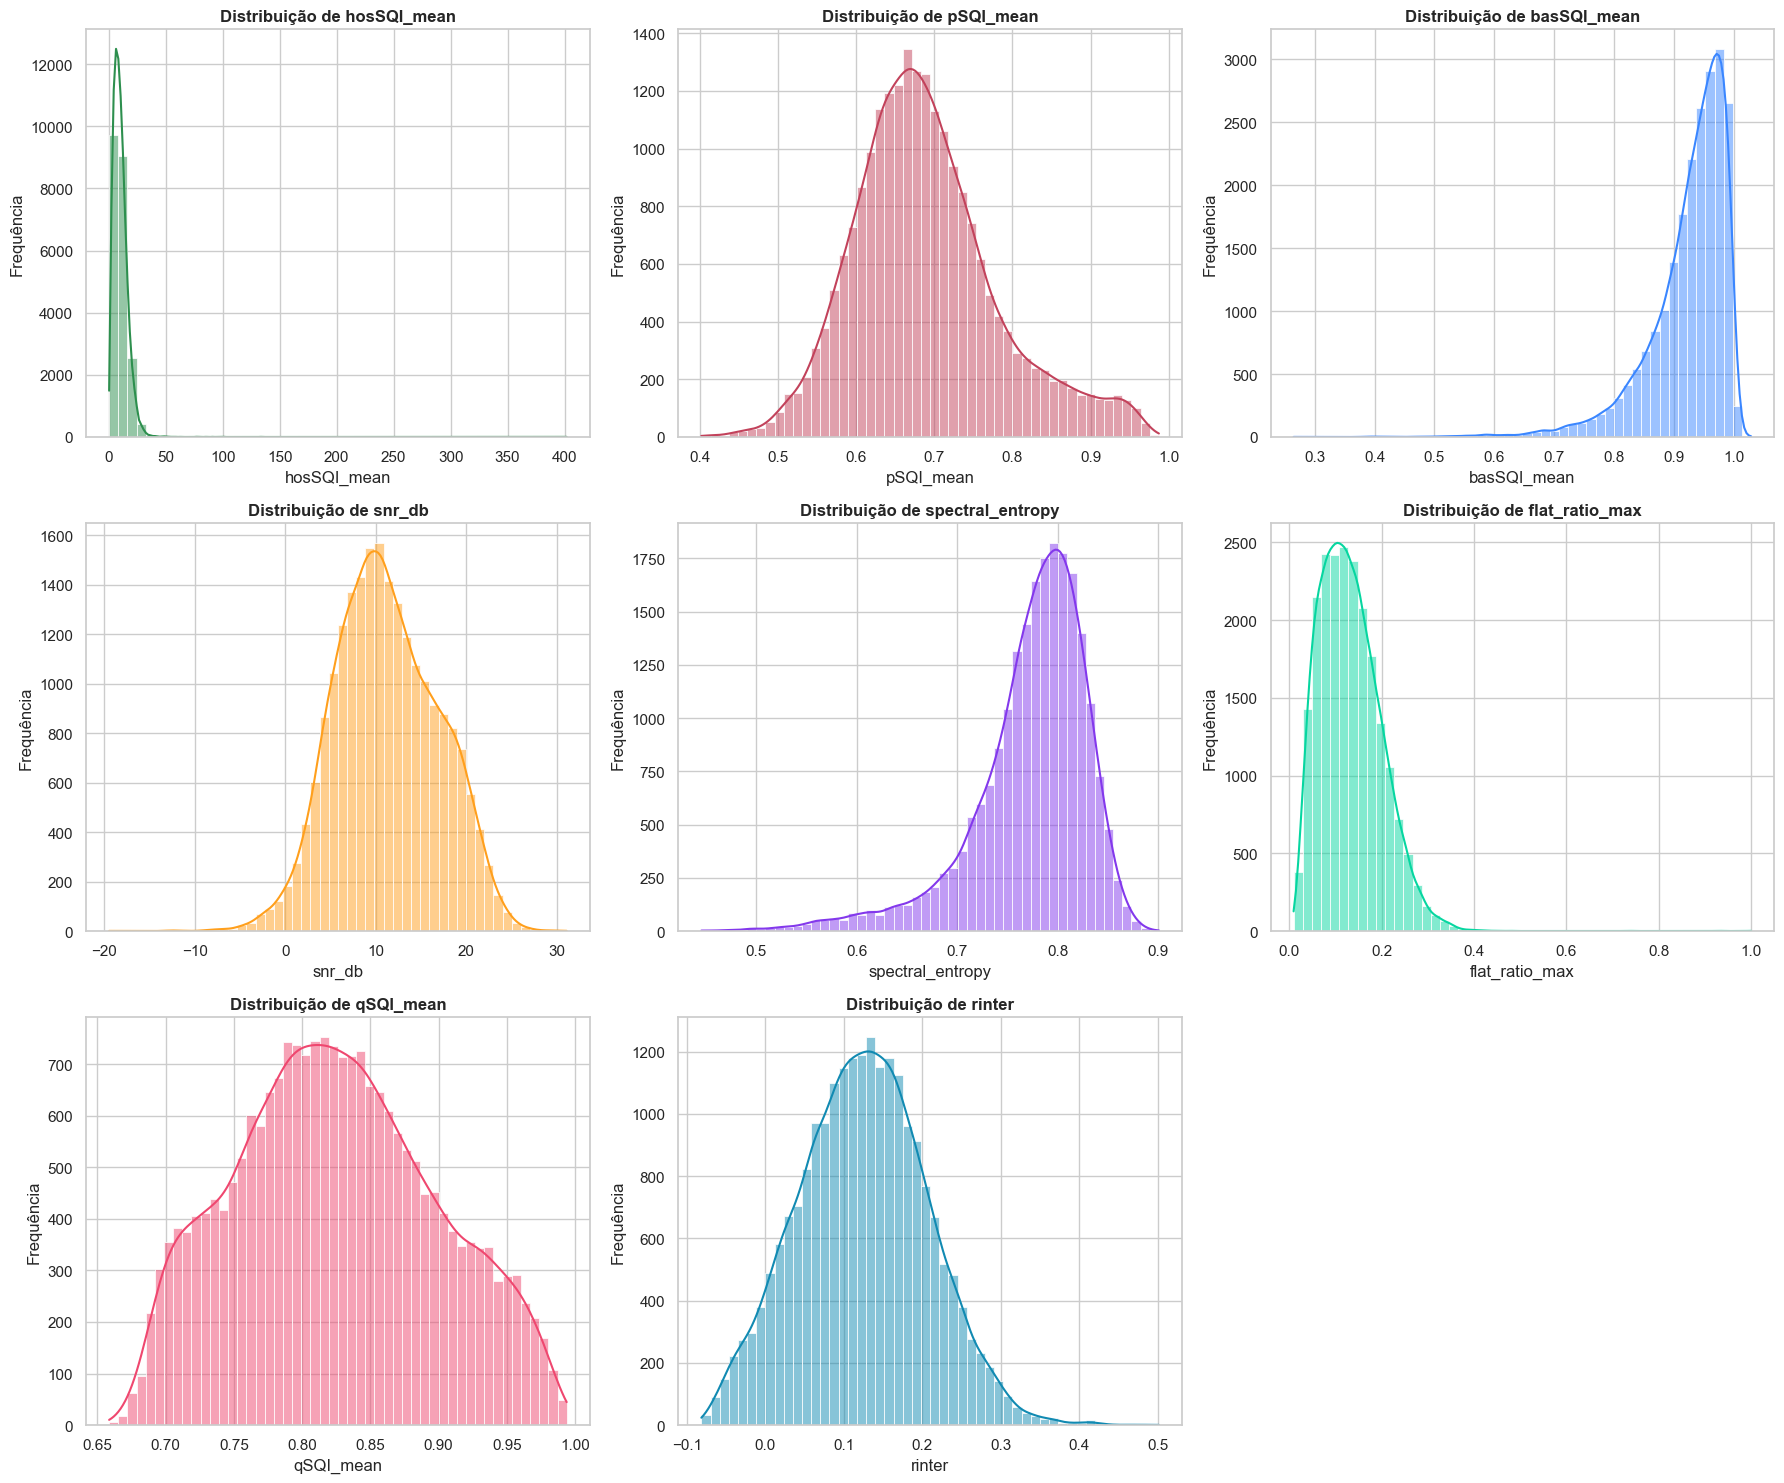

In [18]:
# 2.6 Distribuição das Métricas SQI (com cores)

metricas = [
    'hosSQI_mean',
    'pSQI_mean',
    'basSQI_mean',
    'snr_db',
    'spectral_entropy',
    'flat_ratio_max',
    'qSQI_mean',
    'rinter'
]

cores = [
    '#2d8f4e',  # verde
    '#c2425b',  # vermelho
    '#3a86ff',  # azul
    '#ff9f1c',  # laranja
    '#8338ec',  # roxo
    '#06d6a0',  # verde água
    '#ef476f',  # rosa
    '#118ab2'   # azul petróleo
]

n_cols = 3
n_rows = int(np.ceil(len(metricas) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, metric in enumerate(metricas):
    sns.histplot(
        df_sqi[metric],
        bins=50,
        kde=True,
        color=cores[i],
        ax=axes[i]
    )
    
    axes[i].set_title(f'Distribuição de {metric}', fontweight='bold')
    axes[i].set_xlabel(metric)
    axes[i].set_ylabel('Frequência')

# Remove eixos vazios
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
fig.savefig(os.path.join(FIGS_DIR, 'distribuicao_metricas_sqi.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

metricas_info = [
    ('snr_db', 'SNR Mediano (dB)', 5, '#2d8f4e'),
    ('kurtosis', 'Kurtosis (Fisher)', (1, 50), '#8a6dab'),
    ('skewness', 'Skewness', 5, '#c2425b'),
    ('entropy_h_norm', 'Entropia Espectral Normalizada', 0.95, '#cc8f3c'),
    ('flat_ratio', 'Flat Ratio', 0.05, '#3a7ca5'),
    ('rede_50hz_ratio', 'Razão Potência 50 Hz', 0.1, '#6b8e6b')
]

for i, (col, titulo, limiar, cor) in enumerate(metricas_info):
    ax = axes[i // 3, i % 3]
    dados = df_sqi_raw[col].dropna()
    sns.histplot(dados, bins=60, kde=True, ax=ax, color=cor, alpha=0.6)
    if isinstance(limiar, tuple):
        ax.axvline(limiar[0], color='red', linestyle='--', linewidth=1.5, label=f'Limiar: {limiar[0]} a {limiar[1]}')
        ax.axvline(limiar[1], color='red', linestyle='--', linewidth=1.5)
    else:
        ax.axvline(limiar, color='red', linestyle='--', linewidth=1.5,
                   label=f'Limiar: {limiar}')
    mediana_val = dados.median()
    ax.axvline(mediana_val, color='black', linestyle=':', linewidth=1,
               label=f'Mediana: {mediana_val:.2f}')
    ax.set_title(titulo)
    ax.legend(fontsize=8)

plt.tight_layout()
fig.savefig(os.path.join(FIGS_DIR, 'distribuicao_metricas_sqi.png'), dpi=150, bbox_inches='tight')
plt.show()

display(Markdown("**(Espaço para comentário do aluno — dica: verifique se as medianas do dataset estão acima ou abaixo dos limiares. Se a maioria está acima do limiar de SNR e abaixo do de entropia, o dataset tem boa qualidade geral. Note quais métricas são mais problemáticas.)**"))

---

## Seção 3 — SQI Composto e Critério de Decisão

Após a extração individual das métricas de qualidade, o próximo passo consiste em combiná-las em um **índice composto de qualidade (SQI)** capaz de classificar automaticamente os registros de ECG em diferentes níveis de confiabilidade.

Diferentemente de abordagens baseadas em uma única métrica, esta seção adota uma estratégia de **fusão heurística multi-métrica**, amplamente utilizada na literatura para avaliação de sinais biomédicos. Essa abordagem permite capturar diferentes dimensões da qualidade do sinal — incluindo morfologia, estrutura espectral, continuidade e consistência multicanal — resultando em um sistema mais robusto e interpretável.

O método implementado segue a lógica de um sistema **"Gatekeeper"**, no qual critérios críticos são avaliados inicialmente para excluir sinais claramente inválidos, seguidos por uma etapa de decisão baseada em múltiplos limiares. Essa estrutura é particularmente adequada ao dataset PTB-XL, que apresenta características de aquisição do mundo real, incluindo presença de ruídos e artefatos. [[R3.1]](../../../docs/research/A_tool_for_the_real-time_evaluation_of_ECG_signal_quality_and_activity_--_Application_to_submaximal_treadmill_test%20in_horses.pdf)

---

### 3.1 Cálculo do Score Consolidado

A classificação da qualidade dos sinais é realizada por meio de um sistema hierárquico composto por duas etapas: um **filtro de exclusão crítica (Hard Gate)** e um **sistema de votação baseado em limiares**.

#### 1. Filtro de Exclusão Crítica (Hard Gate)

Nesta etapa, são identificadas falhas graves de aquisição que inviabilizam qualquer análise clínica confiável. Se um registro falhar em qualquer um dos critérios abaixo, ele é automaticamente classificado como **Inaceitável (U)**:

- **`flat_ratio_max > 0.05`** → indica presença significativa de saturação ou linha plana  [[R3.2]](../../../docs/research/EcgScorer_-_An_open_source_MATLAB_toolbox_for_ECG_signal.pdf)
- **`snr_db < 0`** → sinal dominado por ruído, sem integridade clínica  [[R3.3]](../../../docs/research/Robustness_of_electrocardiogram_signal_quality_ind.pdf) [[R3.4]](../../../docs/research/Method_to_Filter_ECGs_and_Evaluate_Clinical_Parameter_Distortion_using_Realistic_ECG_Model_Parameter_Fitting.pdf)

Esses critérios são conservadores e garantem que sinais degenerados não avancem para etapas posteriores.

---

#### 2. Sistema de Votação por Métricas

Para os registros que passam no filtro inicial, aplica-se um sistema de pontuação baseado em limiares definidos para cada métrica. Cada indicador contribui para a avaliação global do sinal conforme seu desempenho.

**Critérios de avaliação:**

- **`hosSQI_mean`** [[R3.1]](../../../docs/research/A_tool_for_the_real-time_evaluation_of_ECG_signal_quality_and_activity_--_Application_to_submaximal_treadmill_test%20in_horses.pdf)
  - Excelente: > 0.8
  - Aceitável: 0.5 – 0.8

- **`qSQI_mean`** [[R3.5]](../../../docs/research/SQI_Quality_Evaluation_Mechanism_of_Single-Lead_ECG_Signal_Based_on_Simple_Heuristic_Fusion_and_Fuzzy_Comprehensive_Evaluation.pdf)
  - Excelente: > 0.9
  - Aceitável: 0.6 – 0.9

- **`rinter`** [[R3.6]](../../../docs/research/A_Novel_Method_and_Python_Library_for_ECG_Signal_Quality_Assessment.pdf)
  - Excelente: > 0.6
  - Aceitável: 0.3 – 0.6

- **`pSQI_mean`** [[R3.5]](../../../docs/research/SQI_Quality_Evaluation_Mechanism_of_Single-Lead_ECG_Signal_Based_on_Simple_Heuristic_Fusion_and_Fuzzy_Comprehensive_Evaluation.pdf)
  - Excelente: 0.5 – 0.8
  - Aceitável: 0.4 – 0.5

- **`basSQI_mean`** [[R3.5]](../../../docs/research/SQI_Quality_Evaluation_Mechanism_of_Single-Lead_ECG_Signal_Based_on_Simple_Heuristic_Fusion_and_Fuzzy_Comprehensive_Evaluation.pdf)
  - Excelente: > 0.95
  - Aceitável: 0.9 – 0.95

- **`spectral_entropy`** [[R3.6]](../../../docs/research/A_Novel_Method_and_Python_Library_for_ECG_Signal_Quality_Assessment.pdf)
  - Excelente: ≤ 0.8
  - Aceitável: 0.8 – 0.95

---

#### 3. Regra de Decisão Final

A classificação final do registro segue a lógica proposta na literatura [[R3.5]](../../../docs/research/SQI_Quality_Evaluation_Mechanism_of_Single-Lead_ECG_Signal_Based_on_Simple_Heuristic_Fusion_and_Fuzzy_Comprehensive_Evaluation.pdf):

- **Excelente (G):**
  - Atende a pelo menos **6 critérios no nível Excelente**

- **Aceitável (A):**
  - Passa no filtro de exclusão
  - Apresenta desempenho intermediário nas métricas

- **Inaceitável (U):**
  - Falha no filtro de exclusão  
  **ou**
  - Falha em pelo menos 3 critérios simultaneamente (indicando degradação global)

---

#### Justificativa Metodológica

A utilização de múltiplas métricas combinadas permite capturar diferentes aspectos da qualidade do sinal, superando abordagens baseadas em indicadores isolados. Métricas como **hosSQI** e **rinter** são particularmente relevantes em ECGs de 12 derivações, enquanto índices espectrais como **basSQI** e **entropia** permitem detectar ruídos específicos do ambiente de aquisição.

Essa abordagem garante um equilíbrio entre **robustez, interpretabilidade e eficiência computacional**, sendo adequada tanto para análise offline quanto para aplicações em tempo real.


In [ ]:
# 3.1 Classificação SQI (Gatekeeper)

def classify_sqi(row):
    """
    Classifica um registro em:
    G (Excelente), A (Aceitável), U (Inaceitável)
    """

    # -------------------------
    # PASSO 1: HARD GATE
    # -------------------------
    if (row['flat_ratio_max'] > 0.4) or (row['snr_db'] < 0):
        return 'U'

    # -------------------------
    # PASSO 2: VOTAÇÃO
    # -------------------------

    score_G = 0
    score_A_fail = 0

    # hosSQI
    if row['hosSQI_mean'] > 0.8:
        score_G += 1
    elif row['hosSQI_mean'] < 0.5:
        score_A_fail += 1

    # qSQI
    if row['qSQI_mean'] > 0.9:
        score_G += 1
    elif row['qSQI_mean'] < 0.6:
        score_A_fail += 1

    # rinter
    if row['rinter'] > 0.6:
        score_G += 1
    elif row['rinter'] < 0.3:
        score_A_fail += 1

    # pSQI
    if 0.5 <= row['pSQI_mean'] <= 0.8:
        score_G += 1
    elif row['pSQI_mean'] < 0.4:
        score_A_fail += 1

    # basSQI
    if row['basSQI_mean'] > 0.95:
        score_G += 1
    elif row['basSQI_mean'] < 0.9:
        score_A_fail += 1

    # spectral entropy
    if row['spectral_entropy'] <= 0.8:
        score_G += 1
    elif row['spectral_entropy'] > 0.95:
        score_A_fail += 1

    # -------------------------
    # DECISÃO FINAL
    # -------------------------

    # Excelente
    if score_G >= 6:
        return 'G'

    # Inaceitável (múltiplas falhas)
    if score_A_fail >= 2:
        return 'U'

    # Caso intermediário
    return 'A'


# ------------------------------
# Aplicação no DataFrame
# ------------------------------

df_sqi['quality_class'] = df_sqi.apply(classify_sqi, axis=1)


# ------------------------------
# Resumo da Classificação
# ------------------------------

dist = df_sqi['quality_class'].value_counts().sort_index()
pct = df_sqi['quality_class'].value_counts(normalize=True).sort_index() * 100

display(Markdown("### Distribuição das Classes de Qualidade (SQI)"))

display(pd.DataFrame({
    'Quantidade': dist,
    'Percentual (%)': pct.round(2)
}))

### Distribuição das Classes de Qualidade (SQI)

,Quantidade,Percentual (%)
quality_class,,
A,16189,74.26
U,5610,25.74


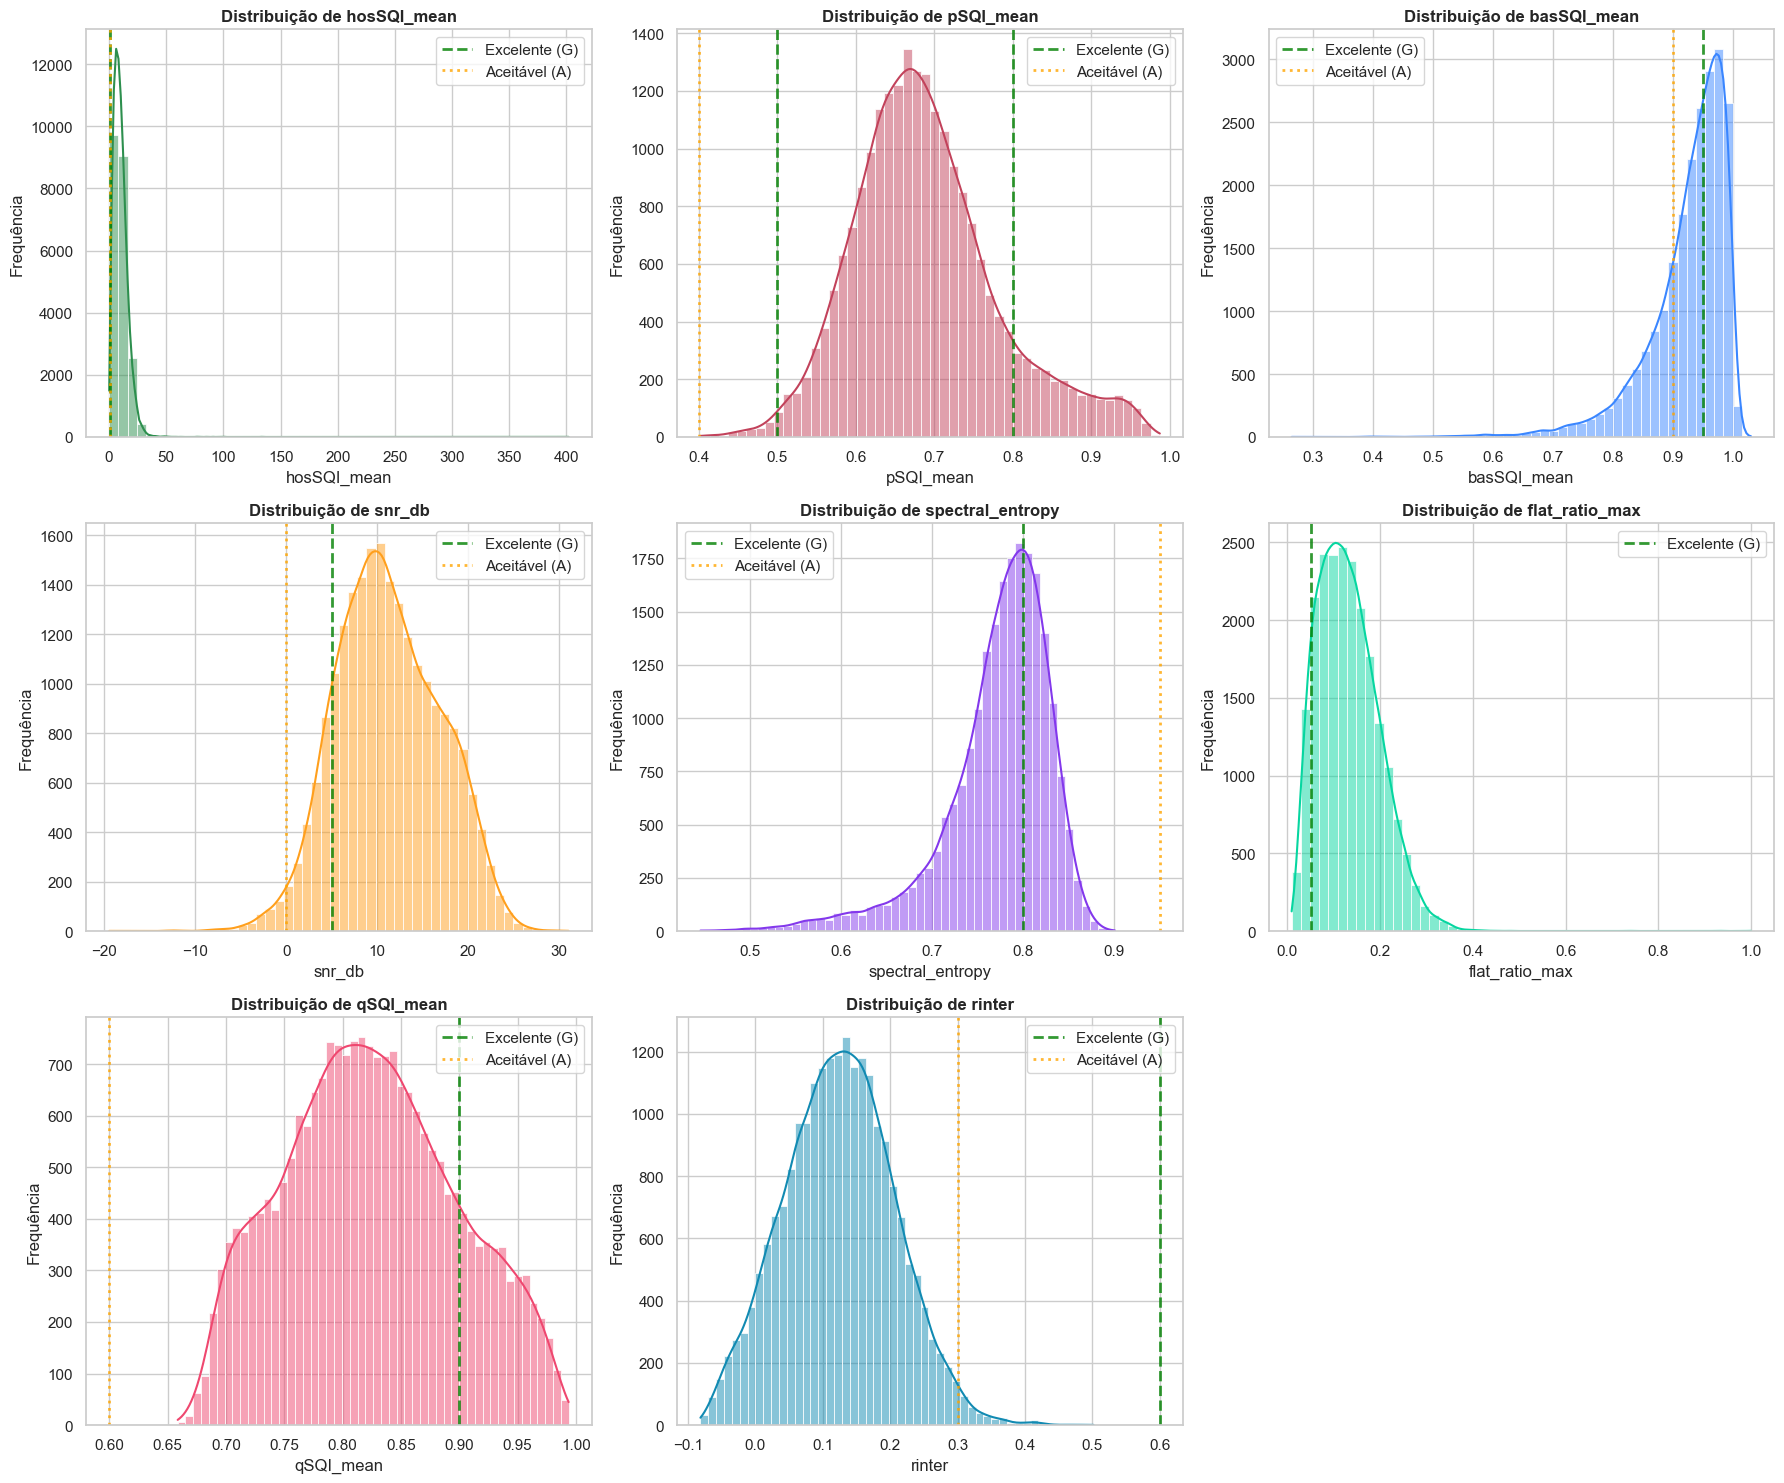

In [30]:
# ------------------------------
# 2.6 Distribuição + Limiar de Decisão
# ------------------------------

import seaborn as sns
import matplotlib.pyplot as plt

metricas = [
    'hosSQI_mean',
    'pSQI_mean',
    'basSQI_mean',
    'snr_db',
    'spectral_entropy',
    'flat_ratio_max',
    'qSQI_mean',
    'rinter'
]

cores = [
    '#2d8f4e',  # verde
    '#c2425b',  # vermelho
    '#3a86ff',  # azul
    '#ff9f1c',  # laranja
    '#8338ec',  # roxo
    '#06d6a0',  # verde água
    '#ef476f',  # rosa
    '#118ab2'   # azul petróleo
]

# 🎯 Limiar por métrica (G e A)
thresholds = {
    'hosSQI_mean': {'G': [0.8], 'A': [0.5]},
    'pSQI_mean': {'G': [0.5, 0.8], 'A': [0.4]},
    'basSQI_mean': {'G': [0.95], 'A': [0.9]},
    'snr_db': {'G': [5], 'A': [0]},  # hard gate também
    'spectral_entropy': {'G': [0.8], 'A': [0.95]},
    'flat_ratio_max': {'G': [0.05]},  # hard gate
    'qSQI_mean': {'G': [0.9], 'A': [0.6]},
    'rinter': {'G': [0.6], 'A': [0.3]}
}

n_cols = 3
n_rows = int(np.ceil(len(metricas) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, metric in enumerate(metricas):
    
    ax = axes[i]
    
    sns.histplot(
        df_sqi[metric],
        bins=50,
        kde=True,
        color=cores[i],
        ax=ax
    )

    # 🎯 Plot thresholds
    if metric in thresholds:
        th = thresholds[metric]

        # Linhas Excelente (verde escuro)
        if 'G' in th:
            for val in th['G']:
                ax.axvline(val, color='green', linestyle='--', linewidth=2, alpha=0.8, label='Excelente (G)')

        # Linhas Aceitável (laranja)
        if 'A' in th:
            for val in th['A']:
                ax.axvline(val, color='orange', linestyle=':', linewidth=2, alpha=0.8, label='Aceitável (A)')

    ax.set_title(f'Distribuição de {metric}', fontweight='bold')
    ax.set_xlabel(metric)
    ax.set_ylabel('Frequência')
    
    # Evitar legendas duplicadas
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    if by_label:
        ax.legend(by_label.values(), by_label.keys())

# Remove eixos vazios
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
fig.savefig(os.path.join(FIGS_DIR, 'distribuicao_metricas_sqi_thresholds.png'), dpi=150, bbox_inches='tight')
plt.show()

### 3.3 Validação com Metadados Originais
Cruzamos nosso SQI calculado com as anotações de qualidade originais do dataset para verificar consistência.

In [ ]:
tabela_validacao = pd.crosstab(
    df['has_quality_issues'].replace({True: 'Problema anotado', False: 'Sem problema'}),
    df['sqi_category'],
    normalize='index'
) * 100

display(Markdown("**Porcentagem de cada categoria SQI, separada por presença de problema nos metadados:**"))
display(tabela_validacao.round(1))

# Concordâncias
sem_prob = df[~df['has_quality_issues']]
com_prob = df[df['has_quality_issues']]
taxa_a_limpos = (sem_prob['sqi_category'] == 'A').mean() * 100
taxa_bc_sujos = ((com_prob['sqi_category'] == 'B') | (com_prob['sqi_category'] == 'C')).mean() * 100

display(Markdown(f"""
**Concordância:**
- Dos registros **sem** problema anotado, **{taxa_a_limpos:.1f}%** foram classificados como A.
- Dos registros **com** problema anotado, **{taxa_bc_sujos:.1f}%** caíram em B ou C.
"""))

display(Markdown("**(Espaço para comentário do aluno — dica: discuta o grau de concordância. É esperado que não seja perfeita, pois o SQI captura problemas diferentes dos metadados textuais. Falsos positivos e negativos são normais.)**"))

---
## Seção 4 — Visualizações Comparativas

### 4.1 Painel Comparativo: Categoria A vs. Categoria C
Visualizamos lado a lado registros de alta e baixa qualidade para entender o que cada categoria significa na prática.

In [ ]:
cat_a = df[df['sqi_category'] == 'A'].sample(3, random_state=42).index
cat_c = df[df['sqi_category'] == 'C'].sample(3, random_state=42).index
amostrados = list(cat_a) + list(cat_c)

fig, axes = plt.subplots(6, 3, figsize=(18, 20))
fig.suptitle('Comparação: Categoria A (verde) vs. Categoria C (vermelho)', fontsize=16)

for i, eid in enumerate(amostrados):
    sig = load_ecg(eid, df, DATA_DIR, FS)
    dii = sig[:, 1]
    t = np.arange(len(dii)) / FS
    cor = '#2d8f4e' if i < 3 else '#c0392b'

    # Coluna 1: Sinal DII
    axes[i, 0].plot(t, dii, color=cor, lw=0.8)
    axes[i, 0].set_title(f'ECG {eid} (SQI {df.loc[eid, "sqi_category"]} = {df.loc[eid, "sqi_score"]:.2f})', fontsize=10)
    axes[i, 0].set_ylabel('mV')

    # Coluna 2: Espectro (Welch)
    freqs, psd = signal.welch(dii, fs=FS, nperseg=256)
    axes[i, 1].plot(freqs, 10 * np.log10(psd + 1e-10), color='k')
    axes[i, 1].axvline(0.5, color='gray', linestyle='--', alpha=0.5)
    axes[i, 1].axvline(40, color='gray', linestyle='--', alpha=0.5)
    axes[i, 1].set_xlim(0, 50)
    axes[i, 1].set_title('Espectro de potência', fontsize=10)

    # Coluna 3: Histograma de amplitude
    sns.histplot(dii, kde=True, ax=axes[i, 2], color=cor, alpha=0.7)
    info = f"SNR={df.loc[eid,'snr_db']:.1f}dB | H={df.loc[eid,'entropy_h_norm']:.2f} | K={df.loc[eid,'kurtosis']:.1f}"
    axes[i, 2].set_title(info, fontsize=9)

plt.tight_layout()
plt.subplots_adjust(top=0.94)
fig.savefig(os.path.join(FIGS_DIR, 'painel_sqi_a_vs_c.png'), dpi=150, bbox_inches='tight')
plt.show()

display(Markdown("**(Espaço para comentário do aluno — dica: compare os sinais verdes (A) com os vermelhos (C). Os registros A devem ter morfologia QRS bem definida e espectro concentrado. Os C provavelmente mostram ruído, espectro plano e histograma irregular.)**"))

### 4.2 Mapa de Calor de Correlação entre Métricas SQI
Métricas muito correlacionadas detectam o mesmo tipo de problema e uma delas poderia ser removida.

In [ ]:
fig = plt.figure(figsize=(8, 6))
cols_sqi = ['snr_db', 'kurtosis', 'skewness', 'entropy_h_norm', 'flat_ratio', 'rede_50hz_ratio']
corr_sqi = df[cols_sqi].corr(method='spearman')

sns.heatmap(corr_sqi, annot=True, cmap='coolwarm', fmt=".2f", center=0,
            mask=np.triu(np.ones_like(corr_sqi, dtype=bool)))
plt.title('Correlação de Spearman entre Métricas SQI')
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, 'correlacao_sqi.png'), dpi=150, bbox_inches='tight')
plt.show()

display(Markdown("**(Espaço para comentário do aluno — dica: verifique se há pares de métricas altamente correlacionados (|r| > 0.7). Métricas independentes são desejáveis, pois cada uma captura um problema diferente.)**"))

### 4.3 Distribuição do SNR por Categoria

In [ ]:
fig = plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='snr_db', hue='sqi_category', bins=50, kde=True,
             palette={'A': '#2d8f4e', 'B': '#e67e22', 'C': '#c0392b'})
plt.title('Distribuição do SNR (dB) por Categoria SQI')
plt.xlabel('SNR Mediano das 12 Derivações (dB)')
plt.axvline(5, color='k', linestyle='--', label='Limiar A (≥ 5 dB)')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, 'snr_por_categoria.png'), dpi=150, bbox_inches='tight')
plt.show()

display(Markdown("**(Espaço para comentário do aluno — dica: observe como as categorias se separam no eixo de SNR. Verifique se o limiar de 15 dB faz boa separação entre sinais limpos e ruidosos.)**"))

### 4.4 SNR por Derivação
Algumas derivações são sistematicamente mais ruidosas que outras — precordiais anteriores (V1, V2) costumam ter mais artefatos de movimento. Verificamos isso calculando o SNR individual de cada derivação em uma amostra de 500 registros.

In [ ]:
# Amostra para cálculo de SNR por derivação
amostra_snr_lead = df.sample(min(500, len(df)), random_state=42).index
snr_por_lead = []

nyq = 0.5 * FS
b_bp, a_bp = signal.butter(4, [0.5/nyq, 40/nyq], btype='bandpass')

for eid in tqdm(amostra_snr_lead, desc='SNR por derivação'):
    sig = load_ecg(eid, df, DATA_DIR, FS)
    s_clean = signal.filtfilt(b_bp, a_bp, sig, axis=0)
    noise = sig - s_clean
    rms_c = np.sqrt(np.mean(s_clean**2, axis=0))
    rms_n = np.sqrt(np.mean(noise**2, axis=0))
    rms_n = np.where(rms_n == 0, 1e-10, rms_n)
    snr_leads = 10 * np.log10((rms_c**2) / (rms_n**2))
    for j, lead in enumerate(LEAD_NAMES):
        snr_por_lead.append({'lead': lead, 'snr_db': snr_leads[j]})

df_snr_leads = pd.DataFrame(snr_por_lead)

fig = plt.figure(figsize=(12, 5))
sns.boxplot(data=df_snr_leads, x='lead', y='snr_db',
            order=LEAD_NAMES, palette='coolwarm')
plt.axhline(5, color='red', linestyle='--', alpha=0.5, label='Limiar 5 dB')
plt.title('SNR por Derivação (amostra de 500 registros)')
plt.xlabel('Derivação')
plt.ylabel('SNR (dB)')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, 'snr_por_derivacao.png'), dpi=150, bbox_inches='tight')
plt.show()

display(Markdown("**(Espaço para comentário do aluno — dica: identifique se alguma derivação é sistematicamente mais ruidosa. V1 e V2 costumam ter SNR menor por estarem mais sujeitas a artefatos de movimento torácico. aVR muitas vezes mostra comportamento diferente por ser a derivação mais 'distante' eletricamente.)**"))

---
## Seção 5 — Salvamento e Síntese

Exportamos os dados com as métricas SQI e a lista de registros rejeitados. A partir do próximo entregável, trabalharemos apenas com registros de Categoria A e B.

In [ ]:
caminho_final = '../outputs/ptbxl_com_sqi.csv'
df.to_csv(caminho_final)

# Lista de rejeitados
rejeitados = df[df['sqi_category'] == 'C']
cam_rejeitados = '../outputs/rejected_ecg_ids.txt'
with open(cam_rejeitados, 'w') as fh:
    for item in rejeitados.index:
        fh.write(f"{item}\n")

n_a = len(df[df.sqi_category == 'A'])
n_b = len(df[df.sqi_category == 'B'])
n_c = len(df[df.sqi_category == 'C'])

display(Markdown(f"""
**Arquivos salvos:**
- Dataset com SQI: `{caminho_final}`
- IDs rejeitados: `{cam_rejeitados}`

**Resumo por categoria:**

| Categoria | Registros | Descrição |
|---|---|---|
| A (Alta qualidade) | {n_a} | Aprovados para o pipeline |
| B (Marginal) | {n_b} | Incluídos com ressalva |
| C (Rejeitados) | {n_c} | Excluídos do pipeline |

**(Espaço para comentário do aluno — dica: comente sobre a proporção de dados que sobreviveram ao filtro SQI e se a taxa de rejeição parece razoável para um dataset clínico real coletado ao longo de 7 anos.)**
"""))